<a href="https://colab.research.google.com/github/Sajina-S/timeseries-forecasting/blob/main/notebooks/Timeseriesforecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTING LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# LOAD DATASET AND EXPLORE THE DATA

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/time-series/train.csv")

In [ ]:
data

,date,store,item,sales
0,01-01-2013,1,1,13
1,02-01-2013,1,1,11
2,03-01-2013,1,1,14
3,04-01-2013,1,1,13
4,05-01-2013,1,1,10
...,...,...,...,...
912995,27-12-2017,10,50,63
912996,28-12-2017,10,50,59
912997,29-12-2017,10,50,74
912998,30-12-2017,10,50,62


In [ ]:
data.head()

,date,store,item,sales
0,01-01-2013,1,1,13
1,02-01-2013,1,1,11
2,03-01-2013,1,1,14
3,04-01-2013,1,1,13
4,05-01-2013,1,1,10


colum data type :

In [ ]:
data.dtypes

date     object
store     int64
item      int64
sales     int64
dtype: object

In [ ]:
data.columns

Index(['date', 'store', 'item', 'sales'], dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [ ]:
data.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


The data type of the ‘date’ column was ‘object’ so first we need to convert into the data type datetime64[ns]:

In [ ]:
data.sort_values('date')

,date,store,item,sales
0,01-01-2013,1,1,13
113212,01-01-2013,3,7,40
838134,01-01-2013,10,46,37
175296,01-01-2013,7,10,25
502150,01-01-2013,6,28,44
...,...,...,...,...
619013,31-12-2017,9,34,21
620839,31-12-2017,10,34,32
622665,31-12-2017,1,35,55
598927,31-12-2017,8,33,100


In [ ]:
data['date']=pd.to_datetime(data['date'])

In [ ]:
data

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-02-01,1,1,11
2,2013-03-01,1,1,14
3,2013-04-01,1,1,13
4,2013-05-01,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [ ]:
data.set_index('date')

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-02-01,1,1,11
2013-03-01,1,1,14
2013-04-01,1,1,13
2013-05-01,1,1,10
...,...,...,...
2017-12-27,10,50,63
2017-12-28,10,50,59
2017-12-29,10,50,74


Checking if there is any null values:

In [ ]:
data.isna().sum()

date     0
store    0
item     0
sales    0
dtype: int64

No null values are there.

Plotting the column 'sales':

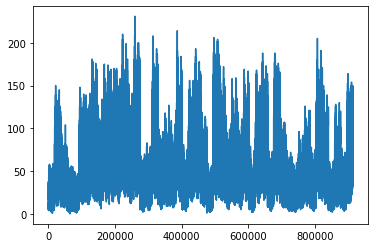

In [ ]:
import matplotlib.pyplot as plt
plt.plot(data['sales'])

In [ ]:
data['store'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [ ]:
for i in range(1,11):
  print('store id :',i)
  y=data[data['store']==i]
  print(y.nunique())

store id : 1
date     1826
store       1
item       50
sales     150
dtype: int64
store id : 2
date     1826
store       1
item       50
sales     207
dtype: int64
store id : 3
date     1826
store       1
item       50
sales     183
dtype: int64
store id : 4
date     1826
store       1
item       50
sales     169
dtype: int64
store id : 5
date     1826
store       1
item       50
sales     126
dtype: int64
store id : 6
date     1826
store       1
item       50
sales     130
dtype: int64
store id : 7
date     1826
store       1
item       50
sales     119
dtype: int64
store id : 8
date     1826
store       1
item       50
sales     195
dtype: int64
store id : 9
date     1826
store       1
item       50
sales     170
dtype: int64
store id : 10
date     1826
store       1
item       50
sales     179
dtype: int64


The null hypothesis of the test is:
   

>  H0: Time series is non-stationary





We are going to check if the null hypothesis is true or not;

> we are conserning only ITEM 1



In [ ]:
data1=data[data['item']==1]

In [ ]:
data1

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-02-01,1,1,11
2,2013-03-01,1,1,14
3,2013-04-01,1,1,13
4,2013-05-01,1,1,10
...,...,...,...,...
18255,2017-12-27,10,1,19
18256,2017-12-28,10,1,12
18257,2017-12-29,10,1,23
18258,2017-12-30,10,1,26


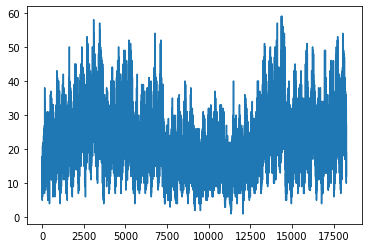

In [ ]:
plt.plot(data1['sales'])

In [ ]:
from statsmodels.tsa.stattools import adfuller
data2=data1.sales

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
result=adfuller(data2)

In [ ]:
print('ADF Statistic: %f' % result[0])

ADF Statistic: -7.155320


In [ ]:
print('p-value: %f' % result[1])

p-value: 0.000000


In [ ]:
print('Critical Values:')
for key, value in result[4].items():
	print('\t%s: %.3f' % (key, value))

Critical Values:
	1%: -3.431
	5%: -2.862
	10%: -2.567


p-value is less than 0.05 there for we reject the hypothesis.That is data is stationary.

Grouping stores and item:

In [ ]:
data.groupby(["store", "item"]).agg({"sales": ["sum", "mean", "median", "std"]})

sales                             
               sum       mean median        std
store item                                     
1     1      36468  19.971522   19.0   6.741022
      2      97050  53.148959   52.0  15.005779
      3      60638  33.208105   33.0  10.072529
      4      36440  19.956188   20.0   6.640618
      5      30335  16.612815   16.0   5.672102
...            ...        ...    ...        ...
10    46    120601  66.046550   65.0  18.114991
      47     45204  24.755750   24.0   7.924820
      48    105570  57.814896   57.0  15.898538
      49     60317  33.032311   32.0  10.091610
      50    135192  74.037240   73.0  19.937566

[500 rows x 4 columns]

In [ ]:
data1

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-02-01,1,1,11
2,2013-03-01,1,1,14
3,2013-04-01,1,1,13
4,2013-05-01,1,1,10
...,...,...,...,...
18255,2017-12-27,10,1,19
18256,2017-12-28,10,1,12
18257,2017-12-29,10,1,23
18258,2017-12-30,10,1,26


In [ ]:
data1['year'] = data1.date.dt.year
data1['month'] = data1.date.dt.month
data1['quarter_of_year'] = data1.date.dt.quarter
data1['week_of_year'] = data1.date.dt.weekofyear
data1['day_of_year'] = data1.date.dt.dayofyear
data1['day_of_month'] = data1.date.dt.day
data1['day_of_week'] = data1.date.dt.dayofweek
data1["is_wknd"] = data1.date.dt.weekday // 4
data1['is_month_start'] = data1.date.dt.is_month_start.astype(int)
data1['is_month_end'] = data1.date.dt.is_month_end.astype(int)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

In [ ]:
data1

,date,store,item,sales,year,month,quarter_of_year,week_of_year,day_of_year,day_of_month,day_of_week,is_wknd,is_month_start,is_month_end
0,2013-01-01,1,1,13,2013,1,1,1,1,1,1,0,1,0
1,2013-02-01,1,1,11,2013,2,1,5,32,1,4,1,1,0
2,2013-03-01,1,1,14,2013,3,1,9,60,1,4,1,1,0
3,2013-04-01,1,1,13,2013,4,2,14,91,1,0,0,1,0
4,2013-05-01,1,1,10,2013,5,2,18,121,1,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18255,2017-12-27,10,1,19,2017,12,4,52,361,27,2,0,0,0
18256,2017-12-28,10,1,12,2017,12,4,52,362,28,3,0,0,0
18257,2017-12-29,10,1,23,2017,12,4,52,363,29,4,1,0,0
18258,2017-12-30,10,1,26,2017,12,4,52,364,30,5,1,0,0


# LAG OR SHIFTED FEATURES

We define the function random noise which is a random sample from the normal distribution with scale parameter 1.6 and size parameter being the length of the given data frame.

In [ ]:
#random noise
def random_noise(dataframe):
    return np.random.normal(scale=1.6, size=(len(dataframe),))

Lag features are the values at prior time steps that are considered useful because they are created on the assumption that what happened in the past can influence the future.

In [ ]:
def lag_features(dataframe, lags):
    for lag in lags:
        dataframe['sales_lag_' + str(lag)] = dataframe.groupby(["store"])['sales'].transform(lambda x: x.shift(lag)) + random_noise(dataframe)
    return dataframe

# ROLLING MEAN FEATURES

A rolling means is the calculation to analyse the data points by creating a series of means of a different subset of the full data set.

In [ ]:
def roll_mean_features(dataframe, windows):
    for window in windows:
        dataframe['sales_roll_mean_' + str(window)] = dataframe.groupby(["store"])['sales']. \
                                                          transform(
            lambda x: x.shift(1).rolling(window=window).mean()) + random_noise(
            dataframe)
    return dataframe

# EWM FEATURES

EWM or Exponentially weighted moving average is a type of moving average that places a greater weight and significance on the most recent data points.

In [ ]:
# Exponentially Weighted Mean Features
def ewm_features(dataframe, alphas, lags):
    for alpha in alphas:
        for lag in lags:
            dataframe['sales_ewm_alpha_' + str(alpha).replace(".", "") + "_lag_" + str(lag)] = \
                dataframe.groupby(["store", "item"])['sales'].transform(lambda x: x.shift(lag).ewm(alpha=alpha).mean())
    return dataframe

Assign the dataset 'train.csv' to the variable 'train':

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/time-series/train.csv', parse_dates=['date'])


In [ ]:
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-02-01,1,1,11
2,2013-03-01,1,1,14
3,2013-04-01,1,1,13
4,2013-05-01,1,1,10


Assign the dataset 'train' to the variable 'df'

In [ ]:
df = train

# EXPLORATORY DATA ANALYSIS

In [ ]:
# Let's check the time periods of train and test sets
df["date"].min(), df["date"].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-12-31 00:00:00'))

In [ ]:
df.shape

(913000, 4)

In [ ]:
df.dtypes

date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object

In [ ]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-02-01,1,1,11
2,2013-03-01,1,1,14
3,2013-04-01,1,1,13
4,2013-05-01,1,1,10


In [ ]:
df.tail()

,date,store,item,sales
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62
912999,2017-12-31,10,50,82


In [ ]:
df.isna().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [ ]:
# Distribution of sales
df["sales"].describe([0.10, 0.30, 0.50, 0.70, 0.80, 0.90, 0.95, 0.99])

count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
10%          20.000000
30%          33.000000
50%          47.000000
70%          64.000000
80%          76.000000
90%          93.000000
95%         107.000000
99%         135.000000
max         231.000000
Name: sales, dtype: float64

In [ ]:
# Number of stores
df["store"].nunique()

10

In [ ]:
# Number of items
df["item"].nunique()

50

In [ ]:
# Number of unique items for each store
df.groupby(["store"])["item"].nunique()

store
1     50
2     50
3     50
4     50
5     50
6     50
7     50
8     50
9     50
10    50
Name: item, dtype: int64

In [ ]:
# Sales distribution per store and item
df.groupby(["store", "item"]).agg({"sales": ["sum"]})

sales
               sum
store item        
1     1      36468
      2      97050
      3      60638
      4      36440
      5      30335
...            ...
10    46    120601
      47     45204
      48    105570
      49     60317
      50    135192

[500 rows x 1 columns]

In [ ]:
df

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-02-01,1,1,11
2,2013-03-01,1,1,14
3,2013-04-01,1,1,13
4,2013-05-01,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [ ]:
# Sales statistics per store and item
df.groupby(["store", "item"]).agg({"sales": ["sum", "mean", "median", "std"]})

sales                             
               sum       mean median        std
store item                                     
1     1      36468  19.971522   19.0   6.741022
      2      97050  53.148959   52.0  15.005779
      3      60638  33.208105   33.0  10.072529
      4      36440  19.956188   20.0   6.640618
      5      30335  16.612815   16.0   5.672102
...            ...        ...    ...        ...
10    46    120601  66.046550   65.0  18.114991
      47     45204  24.755750   24.0   7.924820
      48    105570  57.814896   57.0  15.898538
      49     60317  33.032311   32.0  10.091610
      50    135192  74.037240   73.0  19.937566

[500 rows x 4 columns]

# FEATURE ENGINEERING




In [ ]:
# Date Features
def create_date_features(df):
    df['month'] = df.date.dt.month
    df['day_of_month'] = df.date.dt.day
    df['day_of_year'] = df.date.dt.dayofyear
    df['week_of_year'] = df.date.dt.weekofyear
    df['day_of_week'] = df.date.dt.dayofweek
    df['year'] = df.date.dt.year
    df["is_wknd"] = df.date.dt.weekday // 4
    df['is_month_start'] = df.date.dt.is_month_start.astype(int)
    df['is_month_end'] = df.date.dt.is_month_end.astype(int)
    return df

In [ ]:
# Date Features
df = create_date_features(df)
df.head()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.
  


,date,store,item,sales,month,day_of_month,day_of_year,week_of_year,day_of_week,year,is_wknd,is_month_start,is_month_end
0,2013-01-01,1,1,13,1,1,1,1,1,2013,0,1,0
1,2013-02-01,1,1,11,2,1,32,5,4,2013,1,1,0
2,2013-03-01,1,1,14,3,1,60,9,4,2013,1,1,0
3,2013-04-01,1,1,13,4,1,91,14,0,2013,0,1,0
4,2013-05-01,1,1,10,5,1,121,18,2,2013,0,1,0


In [ ]:
df.isna().sum()

date              0
store             0
item              0
sales             0
month             0
day_of_month      0
day_of_year       0
week_of_year      0
day_of_week       0
year              0
is_wknd           0
is_month_start    0
is_month_end      0
dtype: int64

In [ ]:
df.groupby(["store", "item", "month"]).agg({"sales": ["sum", "mean", "median", "std"]})

sales                             
                    sum       mean median        std
store item month                                    
1     1    1       2484  16.025806   15.0   6.363398
           2       2303  16.333333   16.0   5.852553
           3       2978  19.212903   19.0   5.923744
           4       3043  20.286667   20.0   6.106808
           5       3385  21.838710   21.0   6.971634
...                 ...        ...    ...        ...
10    50   8      12445  80.290323   81.0  18.522351
           9      11551  77.006667   78.5  17.796952
           10     11317  73.012903   72.0  16.922277
           11     11211  74.740000   74.0  17.617651
           12      9803  63.245161   61.0  18.146354

[6000 rows x 4 columns]

In [ ]:
# Lag/Shifted Features
# Below sort_values() is so important!
df.sort_values(by=['store', 'item', 'date'], axis=0, inplace=True)

In [ ]:
df = lag_features(df, [91, 98, 105, 112, 119, 126, 182, 364, 546, 728])

In [ ]:
df

,date,store,item,sales,month,day_of_month,day_of_year,week_of_year,day_of_week,year,...,sales_lag_91,sales_lag_98,sales_lag_105,sales_lag_112,sales_lag_119,sales_lag_126,sales_lag_182,sales_lag_364,sales_lag_546,sales_lag_728
0,2013-01-01,1,1,13,1,1,1,1,1,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,2013-01-02,1,1,11,1,2,2,1,2,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,2013-01-03,1,1,15,1,3,3,1,3,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90,2013-01-04,1,1,11,1,4,4,1,4,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,2013-01-05,1,1,16,1,5,5,1,5,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,10,50,63,12,27,361,52,2,2017,...,77.772878,72.742317,86.530470,101.102421,79.706560,102.223514,91.129867,45.819131,80.835768,50.325051
912996,2017-12-28,10,50,59,12,28,362,52,3,2017,...,80.819984,88.778652,93.594931,135.306292,88.242178,88.083332,122.381005,63.813123,90.679777,44.481249
912997,2017-12-29,10,50,74,12,29,363,52,4,2017,...,88.292308,96.019925,95.646066,80.028011,45.148918,100.633651,113.263677,61.347351,43.586244,59.044807
912998,2017-12-30,10,50,62,12,30,364,52,5,2017,...,102.706383,99.404559,94.744054,93.531097,60.440319,91.786947,62.580386,61.854293,59.953309,51.165255


In [ ]:
df.isna().sum()

date                 0
store                0
item                 0
sales                0
month                0
day_of_month         0
day_of_year          0
week_of_year         0
day_of_week          0
year                 0
is_wknd              0
is_month_start       0
is_month_end         0
sales_lag_91       910
sales_lag_98       980
sales_lag_105     1050
sales_lag_112     1120
sales_lag_119     1190
sales_lag_126     1260
sales_lag_182     1820
sales_lag_364     3640
sales_lag_546     5460
sales_lag_728     7280
dtype: int64

In [ ]:
# Rolling Mean Features
df = roll_mean_features(df, [365, 546])

In [ ]:
# Exponentially Weighted Mean Features
alphas = [0.95, 0.9, 0.8, 0.7, 0.5]
lags = [91, 98, 105, 112, 180, 270, 365, 546, 728]

df = ewm_features(df, alphas, lags)

In [ ]:
df.shape

(913000, 70)

ONE-HOT ENCODING :

In [ ]:
df = pd.get_dummies(df, columns=['store', 'item', 'day_of_week', 'month'])

In [ ]:
df.shape

(913000, 145)

Took the logarithm of the sum of 1 and values in the column ‘sales’ for reducing the complexity.

In [ ]:
df['sales'] = np.log1p(df["sales"].values)#sales values are converted to log

In [ ]:
df

,date,sales,day_of_month,day_of_year,week_of_year,year,is_wknd,is_month_start,is_month_end,sales_lag_91,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,2013-01-01,2.639057,1,1,1,2013,0,1,0,NaN,...,0,0,0,0,0,0,0,0,0,0
31,2013-01-02,2.484907,2,2,1,2013,0,0,0,NaN,...,0,0,0,0,0,0,0,0,0,0
59,2013-01-03,2.772589,3,3,1,2013,0,0,0,NaN,...,0,0,0,0,0,0,0,0,0,0
90,2013-01-04,2.484907,4,4,1,2013,1,0,0,NaN,...,0,0,0,0,0,0,0,0,0,0
120,2013-01-05,2.833213,5,5,1,2013,1,0,0,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912995,2017-12-27,4.158883,27,361,52,2017,0,0,0,77.772878,...,0,0,0,0,0,0,0,0,0,1
912996,2017-12-28,4.094345,28,362,52,2017,0,0,0,80.819984,...,0,0,0,0,0,0,0,0,0,1
912997,2017-12-29,4.317488,29,363,52,2017,1,0,0,88.292308,...,0,0,0,0,0,0,0,0,0,1
912998,2017-12-30,4.143135,30,364,52,2017,1,0,0,102.706383,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
df.isna().sum()

date            0
sales           0
day_of_month    0
day_of_year     0
week_of_year    0
               ..
month_8         0
month_9         0
month_10        0
month_11        0
month_12        0
Length: 145, dtype: int64

In [ ]:
df.head()

,date,sales,day_of_month,day_of_year,week_of_year,year,is_wknd,is_month_start,is_month_end,sales_lag_91,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,2013-01-01,2.639057,1,1,1,2013,0,1,0,NaN,...,0,0,0,0,0,0,0,0,0,0
31,2013-01-02,2.484907,2,2,1,2013,0,0,0,NaN,...,0,0,0,0,0,0,0,0,0,0
59,2013-01-03,2.772589,3,3,1,2013,0,0,0,NaN,...,0,0,0,0,0,0,0,0,0,0
90,2013-01-04,2.484907,4,4,1,2013,1,0,0,NaN,...,0,0,0,0,0,0,0,0,0,0
120,2013-01-05,2.833213,5,5,1,2013,1,0,0,NaN,...,0,0,0,0,0,0,0,0,0,0


Filled the NA values with 0 in the datase

In [ ]:
df = df.fillna(0)

In [ ]:
df.shape

(913000, 145)

# MODELLING

Define x and y:

In [ ]:
x = df.drop(['date', "sales", "year"],axis=1)

In [ ]:
y = df['sales']

In [ ]:
y.shape

(913000,)

Define test and train:

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=67,test_size=0.2)

# LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
model=lr.fit(x_train, y_train)
lr.score(x_test, y_test)

0.8562117462712348

In [ ]:
#TESTING THE MODEL WITH TEST DATA
prediction=model.predict(x_test)
print(prediction)

[3.68962946 4.27073015 4.03268557 ... 3.80176798 4.37133776 4.41658465]


In [ ]:
from sklearn.metrics import mean_squared_error
print('MSE is:' , mean_squared_error(y_test,prediction))

MSE is: 0.04795428433226954


In [ ]:
from sklearn.metrics import r2_score
print('R Squared value is:' , r2_score(y_test,prediction))

R Squared value is: 0.8562117462712348


# DECISION TREE REGRESSOR

In [ ]:
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor()
model1 = tree.fit(x_train,y_train)

In [ ]:
#TESTING THE MODEL WITH TEST DATA
prediction = model1.predict(x_test)
print(prediction)

[4.2341065  4.35670883 4.20469262 ... 3.98898405 4.4543473  4.36944785]


In [ ]:
print('MSE IS ', mean_squared_error(y_test,prediction))

MSE IS  0.06879341928873058


In [ ]:
print('R SQUARED VALUE IS', r2_score(y_test,prediction))

R SQUARED VALUE IS 0.7937267594482484


# LASSO REGRESSOR

In [ ]:
from sklearn.linear_model import LassoCV
lasso = LassoCV()
#TRAIN MODEL
model2 = lasso.fit(x_train,y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.464e+02, tolerance: 2.449e+01
  coef_, l1_reg, l2_reg, X, y, max_iter, tol, rng, random, positive


In [ ]:
#TESTING THE MODEL WITH TEST DATA
prediction = model2.predict(x_test)
print(prediction)

[3.6508569  4.19675601 4.06172731 ... 3.43302524 4.22120384 4.47729299]


In [ ]:
print('MSE IS ', mean_squared_error(y_test,prediction))

MSE IS  0.09081912415862772


In [ ]:
print('R SQUARED VALUE IS', r2_score(y_test,prediction))

R SQUARED VALUE IS 0.7276839087522888


# KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
neighbor = KNeighborsRegressor(n_neighbors=4)
#TRAIN DATA
model3=neighbor.fit(x_train,y_train)

In [ ]:
#TESTING THE MODEL WITH TEST DATA
prediction = model3.predict(x_test)
print(prediction)

In [ ]:
print('MSE IS ', mean_squared_error(y_test,prediction))

In [ ]:
print('R SQUARED VALUE IS', r2_score(y_test,prediction))